In [1]:
# Import libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Face')

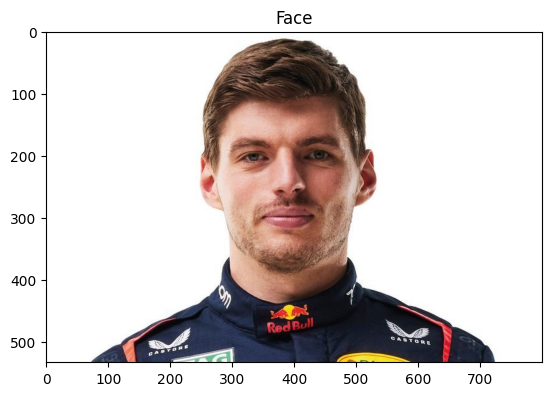

In [2]:
# Load the Face Image
faceImage = cv2.imread('max.jpg')
plt.imshow(faceImage[:,:,::-1]);plt.title("Face")


In [3]:
faceImage.shape

(533, 800, 3)

In [4]:
#resized_faceImage.shape
faceImage.shape

(533, 800, 3)

Text(0.5, 1.0, 'glassPNG')

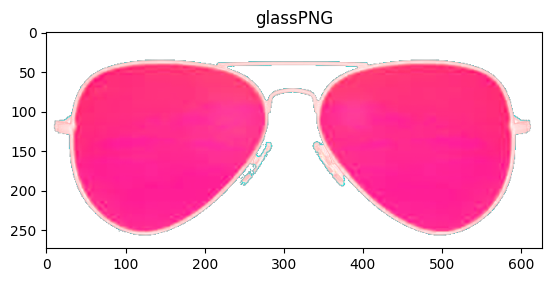

In [10]:
# Load the Sunglass image with Alpha channel
# (http://pluspng.com/sunglass-png-1104.html)
glassPNG = cv2.imread('sunn.png',-1)
plt.imshow(glassPNG[:,:,::-1]);plt.title("glassPNG")

In [11]:
# Resize the image to fit over the eye region
glassPNG = cv2.resize(glassPNG,(190,50))
print("image Dimension ={}".format(glassPNG.shape))

image Dimension =(50, 190, 4)


In [12]:
# Separate the Color and alpha channels
glassBGR = glassPNG[:,:,0:3]
glassMask1 = glassPNG[:,:,3]

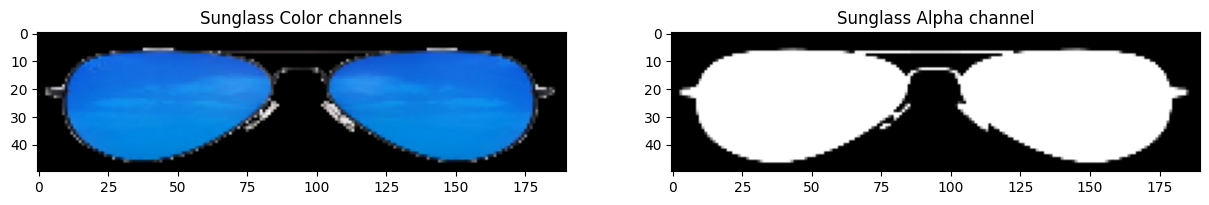

In [13]:
# Display the images for clarity
plt.figure(figsize=[15,15])
plt.subplot(121);plt.imshow(glassBGR[:,:,::-1]);plt.title('Sunglass Color channels');
plt.subplot(122);plt.imshow(glassMask1,cmap='gray');plt.title('Sunglass Alpha channel');

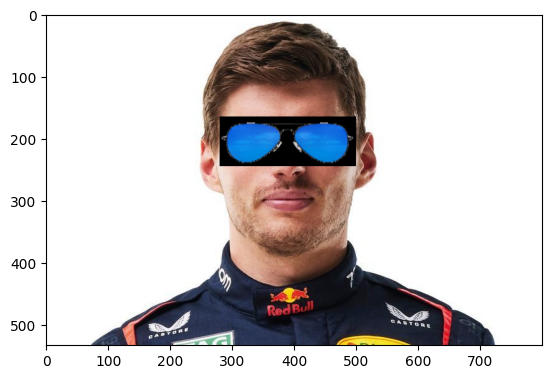

In [28]:
faceWithGlassesNaive = faceImage.copy()

glass_resized = cv2.resize(glassBGR, (220, 80))

# moved a little more right
faceWithGlassesNaive[165:245, 280:500] = glass_resized

plt.imshow(faceWithGlassesNaive[:, :, ::-1])

(np.float64(-0.5), np.float64(799.5), np.float64(532.5), np.float64(-0.5))

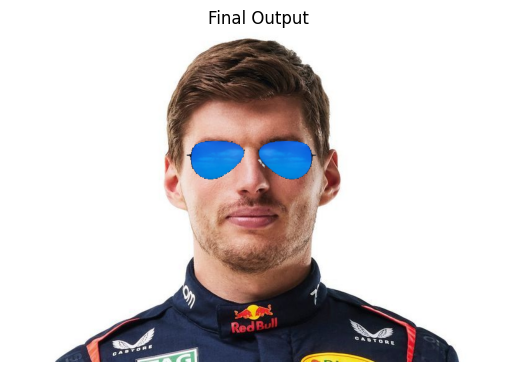

In [30]:
# Resize BOTH glass and mask to SAME size (matching final perfect fit)
glass_resized = cv2.resize(glassBGR, (220, 80))
mask_resized  = cv2.resize(glassMask1, (220, 80))

# Convert mask to 3-channel
glassMask = cv2.merge((mask_resized, mask_resized, mask_resized))

# Normalize mask (0 or 1)
glassMask = (glassMask / 255).astype(np.uint8)

# Copy image
faceWithGlassesArithmetic = faceImage.copy()

# Use your PERFECT coordinates
y1, y2 = 165, 245
x1, x2 = 280, 500

eyeROI = faceWithGlassesArithmetic[y1:y2, x1:x2]

# Apply mask
maskedEye   = cv2.multiply(eyeROI, (1 - glassMask))
maskedGlass = cv2.multiply(glass_resized, glassMask)

# Combine
eyeRoiFinal = cv2.add(maskedEye, maskedGlass)

# Put back into image
faceWithGlassesArithmetic[y1:y2, x1:x2] = eyeRoiFinal

# Show result
plt.imshow(faceWithGlassesArithmetic[:, :, ::-1])
plt.title("Final Output")
plt.axis('off')


(np.float64(-0.5), np.float64(799.5), np.float64(532.5), np.float64(-0.5))

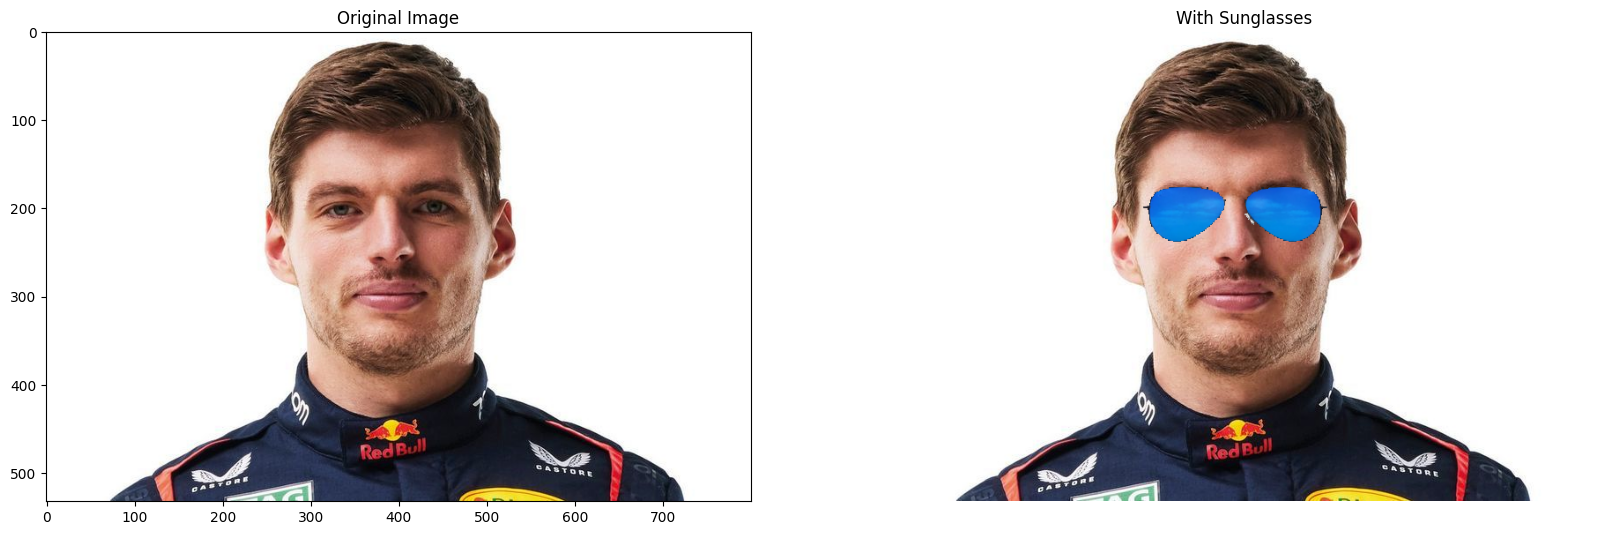

In [32]:

# Replace the eye ROI with the correctly aligned output
faceWithGlassesArithmetic[165:245, 280:500] = eyeRoiFinal

# Display the final result
plt.figure(figsize=[20,20])

plt.subplot(121)
plt.imshow(faceImage[:,:,::-1])
plt.title("Original Image")

plt.subplot(122)
plt.imshow(faceWithGlassesArithmetic[:,:,::-1])
plt.title("With Sunglasses")
plt.axis('off')